In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from scipy.stats import chi2_contingency, ttest_ind

# 1. Load & Explore the Data

In [4]:
# Load the dataset
df = pd.read_csv('streamworks_user_data.csv')

# Display info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   object 
 3   signup_date           1498 non-null   object 
 4   last_active_date      1498 non-null   object 
 5   country               1497 non-null   object 
 6   subscription_type     1497 non-null   object 
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   object 
 11  referred_by_friend    1497 non-null   object 
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), object(7)
memory usage: 164.2+ KB


In [5]:
df.describe()

,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
count,1498.000000,1497.000000,1496.000000,1498.000000,1497.000000,1499.000000,1355.000000
mean,1750.871829,43.738811,39.903342,51.414419,2.498330,0.234156,10.180406
std,433.060980,15.083920,22.978288,28.580117,1.706829,0.423612,3.310705
min,1001.000000,18.000000,0.500000,0.000000,0.000000,0.000000,5.990000
25%,1376.250000,31.000000,19.450000,27.100000,1.000000,0.000000,5.990000
50%,1750.500000,44.000000,40.300000,52.700000,2.000000,0.000000,9.990000
75%,2125.750000,56.000000,59.800000,76.200000,4.000000,0.000000,13.990000
max,2500.000000,69.000000,79.900000,100.000000,5.000000,1.000000,14.990000


In [6]:
df.head()

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99


In [7]:
# value counts for categorical variables
print(df['gender'].value_counts())
print(df['country'].value_counts())
print(df['subscription_type'].value_counts())
print(df['received_promotions'].value_counts())
print(df['referred_by_friend'].value_counts())
print(df['is_churned'].value_counts())
print(df['complaints_raised'].value_counts())

gender
Female    510
Other     506
Male      483
Name: count, dtype: int64
country
Canada     262
India      259
France     254
Germany    246
UK         241
USA        235
Name: count, dtype: int64
subscription_type
Basic       505
Premium     499
Standard    493
Name: count, dtype: int64
received_promotions
No     763
Yes    734
Name: count, dtype: int64
referred_by_friend
Yes    752
No     745
Name: count, dtype: int64
is_churned
0.0    1148
1.0     351
Name: count, dtype: int64
complaints_raised
1.0    259
5.0    251
2.0    251
4.0    248
0.0    244
3.0    244
Name: count, dtype: int64


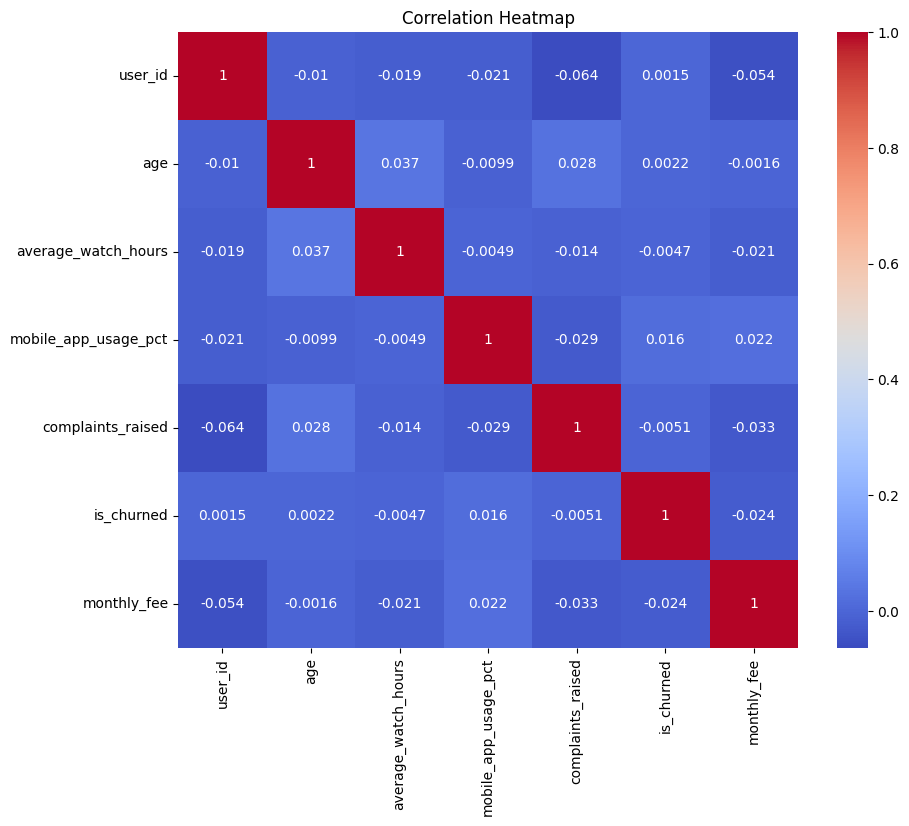

In [8]:
# Correlation matrix for numeric variables
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 2. Clean & Prepare the Data

In [9]:
df.isnull().sum()

,0
user_id,2
age,3
gender,1
signup_date,2
last_active_date,2
country,3
subscription_type,3
average_watch_hours,4
mobile_app_usage_pct,2
complaints_raised,3


In [10]:
# Drop user_id, target_id
df = df.dropna(subset=['is_churned'])
df = df.dropna(subset=['user_id'])

# Fill numerical columns with median
for col in numeric_cols:
  df[col].fillna(df[col].median(), inplace=True)

# Fill categorical columns with mode
categorical_cols = ['gender', 'country', 'subscription_type', 'received_promotions', 'referred_by_friend']
for col in categorical_cols:
  mode_value = df[col].mode()[0]
  df[col].fillna(mode_value, inplace=True)

 # Convert dates to datetime
df['signup_date'] = pd.to_datetime(df['signup_date'])
df['last_active_date'] = pd.to_datetime(df['last_active_date'])

# Fill datetime columns with median
df['signup_date'].fillna(df['signup_date'].median(), inplace=True)
df['last_active_date'].fillna(df['last_active_date'].median(), inplace=True)

# Fill monthly_fee with group mean based on subscription_type
# contextually appropriate due to a high number of missing values
df['monthly_fee'] = df.groupby('subscription_type')['monthly_fee'].transform(lambda x: x.fillna(x.mean()))
df['monthly_fee'].fillna(df['monthly_fee'].mean(), inplace=True)


/tmp/ipython-input-10-3574255605.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-10-3574255605.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [11]:
# Create new features
df['tenure_days'] = (df['last_active_date'] - df['signup_date']).dt.days
df['is_loyal'] = df['tenure_days'] > 180
df['is_loyal'] = df['is_loyal'].astype(int)

# Encode categorical features
# Binary encode Yes/No columns
binary_cols = ['received_promotions', 'referred_by_friend']

for col in binary_cols:
  df[col] = df[col].map({'Yes': 1, 'No': 0})

# One-hot encode multi-category columns
df = pd.get_dummies(df, columns=['gender', 'country', 'subscription_type'], drop_first=True)

In [12]:
df.isnull().sum()

,0
user_id,0
age,0
signup_date,0
last_active_date,0
average_watch_hours,0
mobile_app_usage_pct,0
complaints_raised,0
received_promotions,0
referred_by_friend,0
is_churned,0


# 3. Statistical Analysis & Insights

Chi-square test for gender_Male and churn: chi2=1.1463206830121435, p-value=0.28432068608490824
Chi-square test for gender_Other and churn: chi2=0.9557891453876226, p-value=0.32825008473024764
Chi-square test for received_promotions and churn: chi2=2.4740262855186645, p-value=0.11574110086986023
Chi-square test for referred_by_friend and churn: chi2=0.6403650475198756, p-value=0.42357863909333715
T-test for watch hours: t-test=-0.13859732185940812, p-value=0.8897870256344994


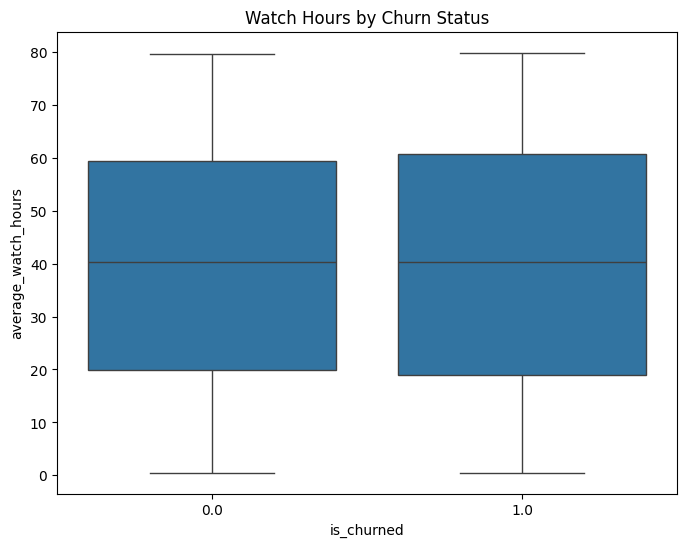

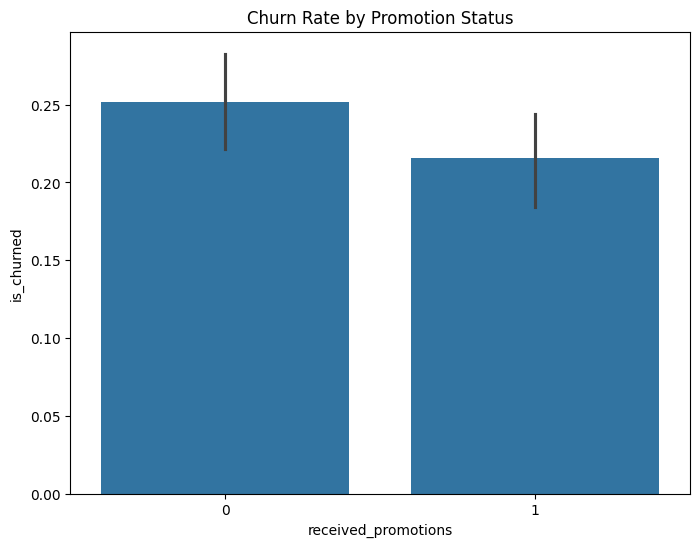

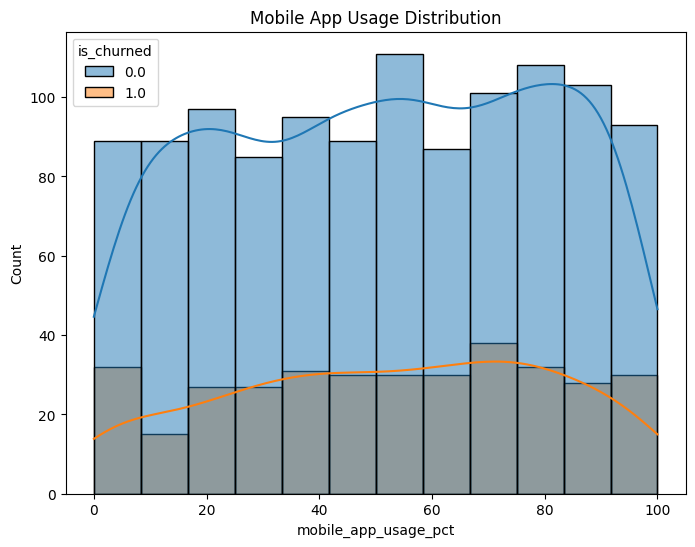

In [13]:
# Chi-square test function
def chi_square_test(col):
  contingency_table = pd.crosstab(df[col], df['is_churned'])
  chi2, p, dof, expected = chi2_contingency(contingency_table)
  print(f'Chi-square test for {col} and churn: chi2={chi2}, p-value={p}')

# Perform chi-square tests
chi_square_test('gender_Male')
chi_square_test('gender_Other')
chi_square_test('received_promotions')
chi_square_test('referred_by_friend')

# T-test for watch time
churned_watch = df[df['is_churned'] == 1]['average_watch_hours']
retained_watch = df[df['is_churned'] == 0]['average_watch_hours']
t_stat, p_val = ttest_ind(churned_watch, retained_watch)
print(f'T-test for watch hours: t-test={t_stat}, p-value={p_val}')

# Visualizations
# Boxplot for churn by watching hours
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_churned', y='average_watch_hours', data=df)
plt.title('Watch Hours by Churn Status')
plt.show()

# Bar plot for churn rate by promotion
plt.figure(figsize=(8, 6))
sns.barplot(x='received_promotions', y='is_churned', data=df)
plt.title('Churn Rate by Promotion Status')
plt.show()

# Histogram for churn rate by active users
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='mobile_app_usage_pct', hue='is_churned', kde=True)
plt.title('Mobile App Usage Distribution')
plt.show()

# 4. Predictive Modelling

Confusion Matrix:
 [[123 106]
 [ 41  30]]
Precision: 0.22058823529411764
Recall: 0.4225352112676056
F1 Score: 0.2898550724637681
ROC AUC: 0.47653607232917156


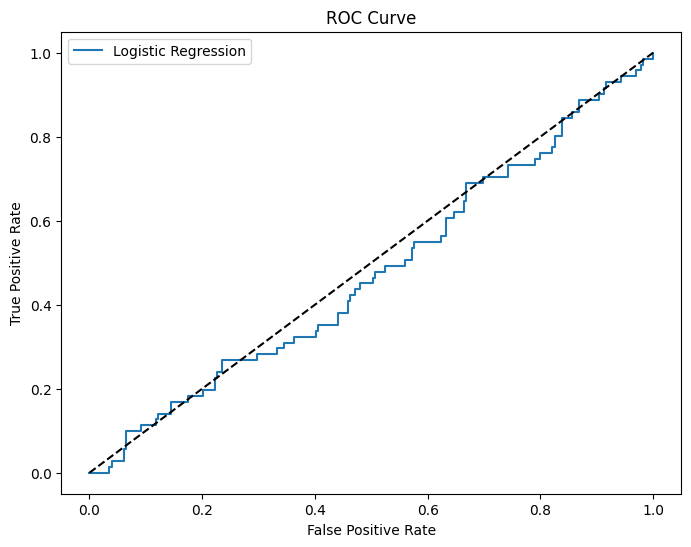

                       Feature  Coefficient
8                     is_loyal     0.133563
17  subscription_type_Standard     0.132334
16   subscription_type_Premium     0.095336


In [14]:
# Prepare feature and targets
X = df.drop(['user_id', 'is_churned', 'signup_date', 'last_active_date'], axis=1)
y = df['is_churned']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit logistic regression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Important predictiors
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients.head(3))

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# GridSearchCV for Logistic Regression
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2']}
grid = GridSearchCV(LogisticRegression(solver='liblinear'), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print('Best params:', grid.best_params_)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)  # RF doesn't need scaling
rf_pred = rf_model.predict(X_test)
print('RF F1 Score:', f1_score(y_test, rf_pred))
print('RF ROC AUC:', roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))


Best params: {'C': 0.01, 'penalty': 'l1'}
RF F1 Score: 0.0
RF ROC AUC: 0.49332677286425974
